In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [4]:
#load saved model

best_model = joblib.load('../Models/best_diabetes_model.pkl')
best_model

# load test data
X_test = pd.read_csv('../Data/X_test.csv')
y_test = pd.read_csv('../Data/y_test.csv').squeeze()

In [5]:
#Evaluate final model on test set

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7402597402597403
Precision: 0.6458333333333334
Recall: 0.5740740740740741
F1 Score: 0.6078431372549019


In [6]:
#add classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



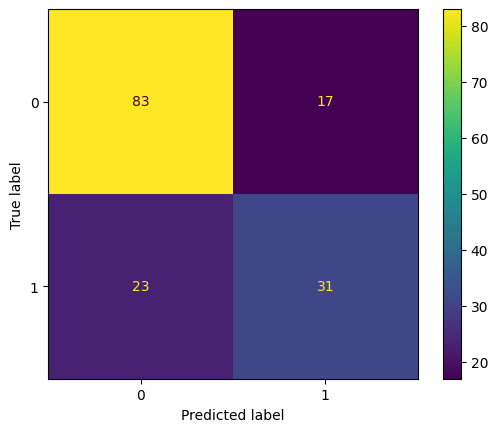

In [7]:
#add confusion metrics

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

ROC AUC: 0.8083333333333335


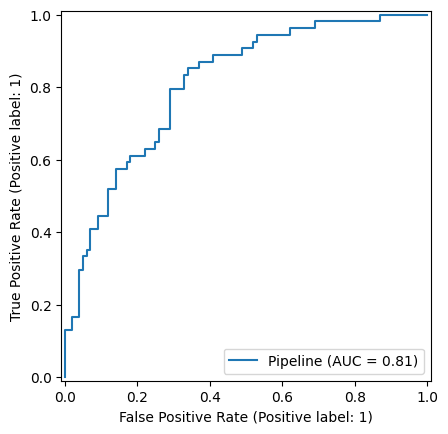

In [8]:
#For probability / ROC AUC:

y_proba = best_model.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

## Conclusion

The Random Forest classifier was selected as the final model after hyperparameter tuning using GridSearchCV. The model achieved an accuracy of 74%, with a ROC AUC score of 0.81, indicating good overall classification performance.

The model demonstrated stronger performance in identifying non-diabetic patients compared to diabetic patients. Recall for diabetic cases was 57%, meaning some diabetes cases were still missed. In healthcare-related classification problems, minimizing false negatives is important because missed diagnoses can lead to delayed treatment.

The project demonstrated the complete machine learning workflow, including:
- data preprocessing
- handling missing values
- feature scaling
- model training
- hyperparameter tuning
- model evaluation
- model serialization using joblib

Future improvements could include:
- improving recall through threshold tuning
- testing additional models such as XGBoost
- handling class imbalance with SMOTE or class weighting
- feature engineering using healthcare domain knowledge
- using larger clinical datasets